# Custom State
Node(Agent)간에 공유되는 상태정보를 커스터마이징할수 있다.

**최신 장소정보 공유**
- tool 장소검색api: naver/kakao/google map api(키워드 검색기반)
- tool 자연어 -> 검색을 위한 키워드추출
    - 나 여기 독산동인데, 여기 괜찮은 까페 추천해줘 -> 독산동 까페

In [1]:
%pip install -Uq langchain langchain-openai langgraph

Note: you may need to restart the kernel to use updated packages.


In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_API_KEY'] = os.getenv('langsmith_key')
os.environ['LANGSMITH_PROJECT'] = 'skn23-langchain'
os.environ['OPENAI_API_KEY'] = os.getenv("openai_key")
os.environ['TAVILY_API_KEY'] = os.getenv("tavily_key")
KAKAO_API_KEY = os.getenv("KAKAO_API_KEY")


## 카카오 장소검색 도구


https://developers.kakao.com/docs/latest/ko/local/dev-guide#search-by-keyword

In [3]:
from langchain.tools import tool
import requests
from typing import List, TypedDict

class KakaoPlace(TypedDict):
    name: str
    address: str
    url: str

@tool
def kakao_place_search(query: str) -> List[KakaoPlace]:
    """
    카카오 장소(키워드) 검색 API
    """
    url = 'https://dapi.kakao.com/v2/local/search/keyword.json'
    headers = {
        'Authorization': f'KakaoAK {KAKAO_API_KEY}'
    }
    params = {
        'query': query,
        'size': 5
    }

    response = requests.get(url, headers=headers, params=params)
    data = response.json()['documents']

    return [
        {
            'name': place['place_name'],
            'address': place['address_name'],
            'url': place['place_url']
        }
        for place in data
    ]

kakao_place_search.invoke({'query': '독산동 맛집'})

c:\nlp\nlp_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[{'name': '진영면옥',
  'address': '서울 금천구 독산동 162-10',
  'url': 'http://place.map.kakao.com/280756271'},
 {'name': '협진식당 5호집',
  'address': '서울 금천구 독산동 293-29',
  'url': 'http://place.map.kakao.com/9623699'},
 {'name': 'KFC 독산동점',
  'address': '서울 금천구 독산동 1043',
  'url': 'http://place.map.kakao.com/1642588258'},
 {'name': '한옥집 숯불갈비 서울본점',
  'address': '서울 금천구 독산동 144-10',
  'url': 'http://place.map.kakao.com/500582252'},
 {'name': '아로가 실비순대국',
  'address': '서울 금천구 독산동 293-19',
  'url': 'http://place.map.kakao.com/16094602'}]

In [4]:
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate

llm = init_chat_model('openai:gpt-4.1-mini')

# @tool
def extract_keyword(user_request: str) -> str:  # 사용자 요청을 장소검색 키워드로 변환하는 도구
    """
    사용자 요청에서 장소검색API를 사용하기 위한 짧고 명확한 키워드를 추출하는 도구
    장소검색도구(kakao_place_search)를 사용하기 전에 사용자의 요청을 먼저 변환하세요.
    """
    prompt = PromptTemplate.from_template('''
당신은 사용자의 요청을 장소검색에 필요한 키워드로 변환하는 전문가입니다.
장문의 사용자 요청에서 키워드를 한 문장으로 추출해주세요.
- 키워드는 띄워쓰기로 구분된 한 문장이어야 합니다.
- 다른 설명은 하지말고, 키워드만 추출합니다.

[사용자요청]
{user_request}


[예시]
- 여기 독산동인데, 소문난 맛집좀 알려줘봐 -> 독산동 맛집
- 부산 핫플 좀 알려줘봐 -> 부산 맛집

[금지어]
- 소문난
- 핫플
''')
    chain = prompt | llm
    response = chain.invoke({'user_request' : user_request})
    return response.content.strip().strip('"').strip("'")   # 응답 텍스트에서 불필요한 따옴표, 공백 제거

In [5]:
print(extract_keyword('여기 독산동인데, 소문난 맛집좀 알려줘봐'))  # 지역+의도 키워드 추출
print(extract_keyword('이따 명동 갈건데, 맛집 리스트 좀 뽑아줘'))  # 장소 기반 맛집 키워드
print(extract_keyword('부산 핫플 좀 알려줘봐'))                   # 금지어 제거 후 키워드
print(extract_keyword('강남에서 디저트 어디서 먹을까?'))          # 카테고리형 키워드
print(extract_keyword('수원에 호텔 어디가 좋아?'))                # 숙박 카테고리 키워드
print(extract_keyword('경기도 광주에 세차장 좀 찾아줘'))           # 업종 검색 키워드

독산동 맛집
명동 맛집
부산 관광 명소
강남 디저트 맛집
수원 호텔
경기도 광주 세차장


# 그래프 구성

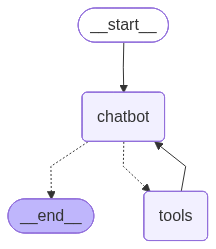

In [8]:
# 사용자 입력 -> 키워드 추출 -> 카카오 장소검색 -> 상태(State)에 결과 저장하는 LangGraph

from langgraph.graph import StateGraph, START, END      # LangGraph 그래프 구성 요소 (시작/끝 포함)
from langgraph.graph.message import add_messages        # messages를 누적(add)하기 위한 규칙
from typing import Annotated, Optional, List, TypedDict # 타입 힌트용
from langchain_core.messages import BaseMessage, ToolMessage  # 기본 메시지 타입 / 도구 결과 메시지
from langgraph.prebuilt import ToolNode, tools_condition # Tool 실행 노드 / 조건 분기 헬퍼
from langchain.chat_models import init_chat_model

class KakaoPlace(TypedDict):
    name: str
    address: str
    url: str

# -------------------------
# 상태(State) 정의
# -------------------------
class State(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages] # 대화 메시지 목록 (자동 누적)
    search_query: Optional[str]                          # 추출된 검색 키워드
    search_results: Optional[List[KakaoPlace]]           # 카카오 장소 검색 결과

# -------------------------
# LLM 및 도구 설정
# -------------------------
model = init_chat_model('openai:gpt-4.1-mini')           # 기본 LLM 초기화

tools = [kakao_place_search, extract_keyword]            # 사용할 도구 목록
model_with_tools = model.bind_tools(tools)               # LLM에 도구 바인딩 (사용 가능하게 연결)

# -------------------------
# 챗봇 노드 정의
# -------------------------
def chatbot(state: State):
    # 마지막 메시지가 ToolMessage인 경우 (도구 실행 결과인 경우)
    if isinstance(state['messages'][-1], ToolMessage):
        # 키워드 추출 도구 결과라면
        if state['messages'][-1].name == 'extract_keyword':
            state['search_query'] = state['messages'][-1].content  # 검색어 상태에 저장
        # 카카오 장소 검색 도구 결과라면
        elif state['messages'][-1].name == 'kakao_place_search':
            state['search_results'] = state['messages'][-1].content  # 검색 결과 상태에 저장

    # 현재까지의 messages를 기반으로 LLM 호출 (필요하면 tool_call 생성)
    response = model_with_tools.invoke(state['messages'])

    # 기존 state 유지 + 새 AI 메시지 추가
    return {**state, 'messages': [response]}

# -------------------------
# LangGraph 워크플로우 구성
# -------------------------
workflow = StateGraph(State)                             # State 타입을 사용하는 그래프 생성

workflow.add_node('chatbot', chatbot)                    # chatbot 노드 추가
workflow.add_node('tools', ToolNode(tools))              # ToolNode 추가 (도구 실제 실행 담당)

workflow.add_edge(START, 'chatbot')                      # 시작 → chatbot
workflow.add_conditional_edges('chatbot', tools_condition)  
# chatbot 결과에 tool_call이 있으면 → tools, 없으면 END

workflow.add_edge('tools', 'chatbot')                    # 도구 실행 후 다시 chatbot으로

# -------------------------
# 그래프 컴파일
# -------------------------
graph = workflow.compile()                               # 실행 가능한 그래프로 컴파일
graph                                                   # 그래프 객체 출력


# 그래프 실행

In [ ]:
initial_state : State = {
    'messages'  : [('human', '춘의역 근처 맛집 추천해줘')],
    'search_query': None,   # 키워드 추출
    'search_results': None  # 장소 검색 결과
}

fianl_state = graph.invoke(initial_state)   # 그래프 실행
fianl_state

{'messages': [HumanMessage(content='춘의역 근처 맛집 추천해줘', additional_kwargs={}, response_metadata={}, id='359b30a4-b956-47eb-b2ee-8fd1ba9601c0'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 122, 'total_tokens': 146, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_75546bd1a7', 'id': 'chatcmpl-D7aoBqL2XRWM3wkiUR8Y2OuDHEbnl', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019c4612-bdd9-7f40-9be0-2d59244eda34-0', tool_calls=[{'name': 'extract_keyword', 'args': {'user_request': '춘의역 근처 맛집 추천해줘'}, 'id': 'call_L83y07fEt65JnafVHwzwP6TF', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 12

In [ ]:
from IPython.display import Markdown    # Jupyter 환경에서 Markdown으로 랜더링

Markdown(fianl_state['messages'][-1].content)   # 마지막 메시지(모델 응답)을 Markdown으로 출력

춘의역 근처 맛집 추천해드릴게요. 

1. 스윗비 - 경기도 부천시 원미구 춘의동 200-1 [장소보기](http://place.map.kakao.com/1385804615)
2. 밥뜨락 - 경기도 부천시 원미구 춘의동 200-1 [장소보기](http://place.map.kakao.com/1856623228)
3. 스타벅스 춘의역DT점 - 경기도 부천시 원미구 춘의동 168-3 [장소보기](http://place.map.kakao.com/543161904)
4. 오연탄주먹고기 - 경기도 부천시 원미구 춘의동 135-1 [장소보기](http://place.map.kakao.com/1061148775)
5. 마장동골목집 - 경기도 부천시 원미구 춘의동 209-3 [장소보기](http://place.map.kakao.com/1333182135)

원하는 음식 종류나 스타일이 있으시면 더 추천해드릴 수 있어요.

# 그래프 디버깅

In [ ]:
for msg in fianl_state['messages']: # 모든 메시지 순회
    msg.pretty_print()              # 메시지 역할/내용을 보기 좋은 포맷으로 출력

================================ Human Message =================================

춘의역 근처 맛집 추천해줘
================================== Ai Message ==================================
Tool Calls:
  extract_keyword (call_L83y07fEt65JnafVHwzwP6TF)
 Call ID: call_L83y07fEt65JnafVHwzwP6TF
  Args:
    user_request: 춘의역 근처 맛집 추천해줘
================================= Tool Message =================================
Name: extract_keyword

춘의역 맛집
================================== Ai Message ==================================
Tool Calls:
  kakao_place_search (call_wl4yAfLQGzv9twuzzNSBmSPI)
 Call ID: call_wl4yAfLQGzv9twuzzNSBmSPI
  Args:
    query: 춘의역 맛집
================================= Tool Message =================================
Name: kakao_place_search

[{"name": "스윗비", "address": "경기 부천시 원미구 춘의동 200-1", "url": "http://place.map.kakao.com/1385804615"}, {"name": "밥뜨락", "address": "경기 부천시 원미구 춘의동 200-1", "url": "http://place.map.kakao.com/1856623228"}, {"name": "스타벅스 춘의역DT점", "address": "경기 부천시 원미구 춘

In [ ]:
# LangGraph 스트리밍 실행 : 노드별 실행 결과를 실시간으로 확인
initial_state : State = {
    'messages'  : [('human', '춘의역 과 부천종합운동장 사이 맛집 추천해줘')],
    'search_query': None,   # 키워드 추출
    'search_results': None  # 장소 검색 결과
}

# 그래프를 스트리밍 방식으로 실행(stream_mode='updates' 기본값으로 노드 실행이 끝날때마다 중간 결과를 전달)
for chunk in graph.stream(initial_state, stream_mode='updates'):
    for node, update in chunk.items():        # chunk 내부(실행된 노드,해당 업데이트) 순회
        print(f"{node} node")
        update['messages'][-1].pretty_print() # 해당 노드에서 추가된 마지막 메시지 출력
    print()

chatbot node
================================== Ai Message ==================================
Tool Calls:
  extract_keyword (call_yEhfIW6v9cJcYTxjcMYQeUbO)
 Call ID: call_yEhfIW6v9cJcYTxjcMYQeUbO
  Args:
    user_request: 춘의역 맛집
  extract_keyword (call_7Cc4fY56KSgb0yShNM9nDD9U)
 Call ID: call_7Cc4fY56KSgb0yShNM9nDD9U
  Args:
    user_request: 부천종합운동장 맛집

tools node
================================= Tool Message =================================
Name: extract_keyword

부천종합운동장 맛집

chatbot node
================================== Ai Message ==================================
Tool Calls:
  kakao_place_search (call_uPB2D8KiYbyDKMDSoMHwcYfj)
 Call ID: call_uPB2D8KiYbyDKMDSoMHwcYfj
  Args:
    query: 춘의역 맛집
  kakao_place_search (call_7DQSlmatMNafon9WLf6BEkKn)
 Call ID: call_7DQSlmatMNafon9WLf6BEkKn
  Args:
    query: 부천종합운동장 맛집

tools node
================================= Tool Message =================================
Name: kakao_place_search

[{"name": "카페복사골 부천", "address": "경기 부천시 원미구 춘의동 